# Unfold Data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial

# local imports
import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

In [3]:
save_result = True
save_fig = save_result

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "unfolding-data-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding-data-20260513


In [ ]:
from pathlib import Path

from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE
from analysis_village.numucc_1p0pi.syst_disk_layout import category_summary_npz_path

# Category summary export from systematics-summary.ipynb (total_xsec for unfolding).
SYST_DISK_ROOT = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final"
CATEGORY_SUMMARY_OUT = (
    Path(PLOTS_BASE) / "syst_uncertainty_breakdown" / "final_selected" / "category_syst_summary.npz"
)
CATEGORY_SUMMARY_NPZ = category_summary_npz_path(SYST_DISK_ROOT)
if not path.isfile(CATEGORY_SUMMARY_NPZ) and CATEGORY_SUMMARY_OUT.is_file():
    CATEGORY_SUMMARY_NPZ = str(CATEGORY_SUMMARY_OUT)
UNFOLDING_SYST_KIND = "xsec"  # total_xsec (GENIE xsec)

print("category summary:", CATEGORY_SUMMARY_NPZ, "exists =", path.isfile(CATEGORY_SUMMARY_NPZ))

In [4]:
ret = get_ana_dfs(option="data_unfolding")
# ret = get_ana_dfs(option="fake_data_test")

mc_hdr_df = ret['hdr']
mc_nu_df = ret['mcnu']
mc_evt_df = ret['evt']

data_evt_df = ret['data']
data_hdr_df = ret['data_hdr']

pot_str = ret['pot_str']
pot_label = ret['pot_label']

Reading file with tag ab, mc_n_split: 6
Reading file with tag ac, mc_n_split: 6
data_tot_pot: 8.572e+19
data tot gates : 1.871e+07
mc_tot_pot: 3.043e+19
mc_pot_scale: 2.817e+00


In [5]:
data_tot_pot = data_hdr_df['pot'].sum()
data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
print("data_tot_pot: %.3e" %(data_tot_pot))
pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_gates = data_hdr_df.nbnbinfo.sum()
print("data tot gates : %.3e" %(data_gates))

data_tot_pot: 8.572e+19
data tot gates : 1.871e+07


In [6]:
from pyanalib.split_df_helpers_new import *

df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE"
keys2load_data = ['hdr', 'evt', 'mcnu']
df_data = dfs_from_dir(search_dir=df_dir, filename_str="sel_mup", keys2load=keys2load_data, n_max_concat=500)
mc_evt_df = df_data['evt']
mc_hdr_df = df_data['hdr']
mc_nu_df = df_data['mcnu']

Found 500 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_024530__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_1002.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_02453

100%|██████████| 500/500 [07:27<00:00,  1.12it/s]


In [7]:
mc_nu_df.columns = pd.MultiIndex.from_tuples([tuple(["mc"] + list(c)) for c in mc_nu_df.columns])     # match # of column levels

In [8]:
mc_tot_pot = mc_hdr_df['pot'].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))

mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_nu_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_nu_df))

mc_evt_df.loc[:,'topo_categ'] = get_topo_category(mc_evt_df)
mc_evt_df.loc[:,'genie_categ'] = get_genie_category(mc_evt_df)

mc_nu_df.loc[:,'topo_categ'] = get_topo_category(mc_nu_df)
mc_nu_df.loc[:,'genie_categ'] = get_genie_category(mc_nu_df)

mc_pot_scale: 6.094e-01


In [9]:
from pyanalib.variable_calculator import *

tki_var_names = ["del_alpha", "del_phi", "del_Tp", "del_p", "del_Tp_x", "del_Tp_y"]

slc_mudf = mc_evt_df.mu.pfp.trk.truth.p
slc_pdf = mc_evt_df.p.pfp.trk.truth.p
slc_P_mu_col = pad_column_name(("totp",), slc_mudf)
slc_P_p_col = pad_column_name(("totp",), slc_pdf)
tki_reco = get_cc1p0pi_tki(slc_mudf, slc_pdf, slc_P_mu_col, slc_P_p_col)
for var_name in tki_var_names:
    mc_evt_df = multicol_add(mc_evt_df, tki_reco[var_name].rename("mc_" + var_name))

mc_mudf = mc_nu_df.mc.mu
mc_pdf = mc_nu_df.mc.p
mc_P_mu_col = pad_column_name(("totp",), mc_mudf)
mc_P_p_col = pad_column_name(("totp",), mc_pdf)
tki_mc = get_cc1p0pi_tki(mc_mudf, mc_pdf, mc_P_mu_col, mc_P_p_col)
for var_name in tki_var_names:
        mc_nu_df = multicol_add(mc_nu_df, tki_mc[var_name].rename("{}".format(var_name)))

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
# --- config for Wiener-SVD unfolding ---
C_type = 2
Norm_type = 0.

In [11]:
pot_label

'Events / Bin (POT=8.57$\\times 10^{19}$)'

In [12]:
data_tot_pot = data_hdr_df['pot'].sum()
print("data_tot_pot", data_tot_pot)

data_tot_pot 8.571948e+19


In [13]:
# per-TPC FV cut

perTPC_inset = 5
def perTPC_cut(df):
    in_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    in_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    perTPC_cut = in_TPC1_cut | in_TPC2_cut
    return perTPC_cut

data_evt_df = data_evt_df[perTPC_cut(data_evt_df)]
mc_evt_df = mc_evt_df[perTPC_cut(mc_evt_df)]
# mc_nu_df = mc_nu_df[perTPC_cut(mc_nu_df)]
# intime_evt_df = intime_evt_df[perTPC_cut(intime_evt_df)]

## GiBUU generator comparison

GiBUU MC is loaded from split CAF dataframes (same pattern as GENIE). **evt** weights use **POT scaling to data** times **`mc.genweight`**; **mcnu** rows use the same POT scale times **`genweight`** from the neutrino table (same exposure as the slice-level weight).

**Wiener `Signal` / `model`** is **`nevts_allmc × xsec_unit`** from **`mcnu`** (truth variable `var_nu_col`) for each generator. The **data** unfolding uses the **GENIE** response matrix and covariance built from GENIE reco counts; folded **GENIE** curves use the corresponding Wiener **`AddSmear`**. Folded **GiBUU** curves use the same **`nevts_allmc × xsec_unit`** signal axis but **`AddSmear`** from a second Wiener filter built from the **GiBUU** response and GiBUU reco-based covariance (so migration matches GiBUU MC). Plotting **`nevts_sel_truth`** next to the wrong **`AddSmear @ model`** combination made both generators look wrong vs the unfolded spectrum.

GiBUU therefore loads **`mcnu`**, matches the **`mc`** MultiIndex like GENIE, adds TKI on `mcnu`, and passes **`signal_hists(gibuu_evt_df, gibuu_mcnu_df, …)`** so **`nevts_allmc`** is defined the same way as for GENIE.

Set `LOAD_GIBUU = True` and point `gibuu_df_dir` / `gibuu_filename_str` at your GiBUU dfs directory (files matched by `dfs_from_dir`).

In [14]:
# --- GiBUU MC (optional): pot scale × genweight; evt + mcnu (for nevts_allmc like GENIE); per-TPC FV on evt ---
LOAD_GIBUU = True  # set True when gibuu_df_dir is valid
gibuu_df_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/MC/BNB_cosmics"  # e.g. "/pnfs/sbnd/scratch/users/.../cafpyana_out/dfs/<tag>__GiBUU-sel_mup"
gibuu_filename_str = "GiBUU-sel_mup"  # substring for dfs_from_dir glob
gibuu_evt_df = None
gibuu_mcnu_df = None

if LOAD_GIBUU and gibuu_df_dir is not None:
    try:
        keys2load_gibuu = ["hdr", "evt", "mcnu"]
        df_gibuu = dfs_from_dir(
            search_dir=gibuu_df_dir,
            filename_str=gibuu_filename_str,
            keys2load=keys2load_gibuu,
            n_max_concat=300,
        )
        gibuu_evt_df = df_gibuu["evt"]
        gibuu_hdr_df = df_gibuu["hdr"]
        gibuu_mcnu_df = df_gibuu["mcnu"]
        gibuu_mcnu_df.columns = pd.MultiIndex.from_tuples(
            [tuple(["mc"] + list(c)) for c in gibuu_mcnu_df.columns]
        )

        gibuu_tot_pot = gibuu_hdr_df["pot"].sum()
        gibuu_pot_scale = data_tot_pot / gibuu_tot_pot
        gw = np.asarray(gibuu_evt_df["mc"]["genweight"], dtype=float)
        gibuu_evt_df["pot_weight"] = gibuu_pot_scale * gw
        gw_nu = np.asarray(gibuu_mcnu_df["mc"]["genweight"], dtype=float)
        gibuu_mcnu_df["pot_weight"] = gibuu_pot_scale * gw_nu

        gibuu_evt_df.loc[gibuu_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
        gibuu_mcnu_df.loc[gibuu_mcnu_df["mc"]["iscc"].isna(), ("mc", "iscc")] = 999
        gibuu_evt_df.loc[:, "topo_categ"] = get_topo_category(gibuu_evt_df)
        gibuu_mcnu_df.loc[:, "topo_categ"] = get_topo_category(gibuu_mcnu_df)

        slc_mudf_g = gibuu_evt_df.mu.pfp.trk.truth.p
        slc_pdf_g = gibuu_evt_df.p.pfp.trk.truth.p
        slc_P_mu_col_g = pad_column_name(("totp",), slc_mudf_g)
        slc_P_p_col_g = pad_column_name(("totp",), slc_pdf_g)
        tki_reco_g = get_cc1p0pi_tki(slc_mudf_g, slc_pdf_g, slc_P_mu_col_g, slc_P_p_col_g)
        for var_name in tki_var_names:
            gibuu_evt_df = multicol_add(gibuu_evt_df, tki_reco_g[var_name].rename("mc_" + var_name))

        mc_mudf_g = gibuu_mcnu_df.mc.mu
        mc_pdf_g = gibuu_mcnu_df.mc.p
        mc_P_mu_col_g = pad_column_name(("totp",), mc_mudf_g)
        mc_P_p_col_g = pad_column_name(("totp",), mc_pdf_g)
        tki_mc_g = get_cc1p0pi_tki(mc_mudf_g, mc_pdf_g, mc_P_mu_col_g, mc_P_p_col_g)
        for var_name in tki_var_names:
            gibuu_mcnu_df = multicol_add(gibuu_mcnu_df, tki_mc_g[var_name].rename("{}".format(var_name)))

        gibuu_evt_df = gibuu_evt_df[perTPC_cut(gibuu_evt_df)]
        print(
            "GiBUU: loaded %d evt rows, %d mcnu rows; gibuu_pot_scale=%.3e"
            % (len(gibuu_evt_df), len(gibuu_mcnu_df), gibuu_pot_scale)
        )
    except Exception as e:
        gibuu_evt_df = None
        gibuu_mcnu_df = None
        print("GiBUU load failed; comparison disabled:", e)
else:
    print("GiBUU comparison disabled (set LOAD_GIBUU True and gibuu_df_dir).")

Found 1 files to process
Files to process: ['/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/MC/BNB_cosmics/GiBUU-sel_mup.df']


100%|██████████| 1/1 [00:07<00:00,  7.89s/it]
/tmp/ipykernel_3947740/3019816623.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '999' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  gibuu_mcnu_df.loc[gibuu_mcnu_df["mc"]["iscc"].isna(), ("mc", "iscc")] = 999
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


GiBUU: loaded 4512 evt rows, 788141 mcnu rows; gibuu_pot_scale=2.292e+00


In [15]:
def get_xsec_unit(tot_pot, 
                  fluxfile="/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root", 
                  detector="SBND",
                  volume=None):

    tot_flux = get_integrated_flux(fluxfile, plot=False)
    tot_flux *= tot_pot
    # print("integrated flux: ", tot_flux)

    V_SBND = get_active_volume(detector)
    if volume is not None:
        # print("using custom volume: ", volume)
        V_SBND = volume

    NTARGETS = RHO * V_SBND * (N_A / M_AR) #/ 40 # divide by 40 to make this per-argon nucleus
    # print("# of targets: ", NTARGETS)
    NTARGETS = NTARGETS / 1e30

    xsec_unit = 1 / (tot_flux * NTARGETS)
    xsec_unit = xsec_unit / 1e30
    # # TODO: fix scalar overflow error in python v3.10+
    # if xsec_unit == 0:
    #     print("XSEC_UNIT is 0, setting to 1e-38")
    #     xsec_unit = 1e-38
    # print("xsec unit: ", xsec_unit)
    return xsec_unit

    

In [16]:
def get_xsec_unit(tot_pot, 
                  fluxfile="/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root", 
                  detector="SBND"):

    tot_flux = get_integrated_flux(fluxfile, plot=False)
    tot_flux = tot_flux * tot_pot
    print("integrated flux: {:.3e}".format(tot_flux))

    V_SBND = get_active_volume(detector)
    # Number of argon nuclei: total mass / mass per nucleus
    # RHO = density (g/cm^3), V_SBND = volume (cm^3), M_AR = molar mass of Ar (g/mol), N_A = Avogadro's number (nuclei/mol)
    NTARGETS = (RHO * V_SBND / M_AR) * N_A
    print("# of argon target nuclei: ", NTARGETS)

    save_factor = 1e30
    NTARGETS = NTARGETS / save_factor

    xsec_unit = 1 / (tot_flux * NTARGETS)

    xsec_unit = xsec_unit / save_factor
    print("xsec unit: ", xsec_unit)
    return float(xsec_unit)

fluxfile = "/exp/sbnd/data/users/munjung/xsec/flux_closure/Gen1FV_flux.root"

xsec_unit = get_xsec_unit(data_tot_pot, fluxfile, detector="SBND_face")

print(xsec_unit)

Integrated flux: 1.553e-08
integrated flux: 1.331e+12
# of argon target nuclei:  1.5058505421519379e+29
xsec unit:  4.989253829141396e-42
4.989253829141396e-42


In [17]:
var_configs = [
    # VariableConfig.all_events(),
            VariableConfig.muon_momentum(),
            # VariableConfig.muon_direction(),
            # VariableConfig.proton_momentum(),
            # VariableConfig.proton_direction(),
            # # VariableConfig.opening_angle(),
            # VariableConfig.tki_del_alpha(),
            # VariableConfig.tki_del_phi(),
            # VariableConfig.tki_del_Tp(),
            # VariableConfig.tki_del_p(),
            # VariableConfig.tki_del_Tp_x(),
            # VariableConfig.tki_del_Tp_y()
            ]

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc","iscc")] = 999
data_evt_df[("mc","iscc")] = 999

/tmp/ipykernel_3947740/3445799127.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_evt_df[("mc","iscc")] = 999


In [18]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

unfolding_plotter = partial(
    overlay_hists,
    breakdown_type=breakdown_type,
    mc_df=mc_evt_df,
    data_df=data_evt_df,
    intime_df=None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

In [19]:

scale = 1.

In [20]:
# ======= systematic uncertainties (category_syst_summary export) ======
_CAT_SYST_LABELS = {
    "flux": "Flux",
    "g4": "G4",
    "mcstat": "MC stat.",
    "detector": "Detector",
    "cosmics": "Cosmics",
    "genie_rate": "GENIE (rate)",
    "genie_xsec": "GENIE (xsec)",
    "pot": "POT",
    "ntargets": "Ntargets",
}


def get_syst_unc(var_config, plot=False, save_fig=False, save_name=None):
    from analysis_village.numucc_1p0pi.syst_category_summary import (
        TOTAL_RATE,
        TOTAL_XSEC,
        load_category_syst_summary,
    )

    frac_uncert_total, frac_cov_matrix_total = get_category_summary_syst_unc(
        var_config,
        syst_kind=UNFOLDING_SYST_KIND,
        syst_disk_root=SYST_DISK_ROOT,
        category_syst_summary_path=CATEGORY_SUMMARY_NPZ,
    )
    total_key = TOTAL_XSEC if UNFOLDING_SYST_KIND == "xsec" else TOTAL_RATE

    if plot:
        summary = load_category_syst_summary(CATEGORY_SUMMARY_NPZ)
        pack = summary["by_var"][var_config.var_save_name]
        for cat_key, cat_blk in pack["categories"].items():
            w = np.asarray(cat_blk["frac_unc_pct"], dtype=float) / 100.0
            label = _CAT_SYST_LABELS.get(cat_key, cat_key)
            plt.hist(
                var_config.bin_centers,
                bins=var_config.bins,
                weights=w,
                histtype="step",
                linewidth=2,
                label=label,
            )
        tot_w = np.asarray(pack[total_key]["frac_unc_pct"], dtype=float) / 100.0
        plt.hist(
            var_config.bin_centers,
            bins=var_config.bins,
            weights=tot_w,
            histtype="step",
            linewidth=2,
            color="k",
            label=f"Total ({total_key})",
        )

        n_data, _ = np.histogram(data_evt_df[var_config.var_evt_reco_col], bins=var_config.bins)
        n_data_err = np.sqrt(n_data * scale)
        data_stat_uncert = n_data_err / (n_data * scale)
        plt.hist(
            var_config.bin_centers,
            bins=var_config.bins,
            weights=data_stat_uncert,
            histtype="step",
            linewidth=2,
            label="Data stat.",
            linestyle="--",
            color="k",
        )

        plt.xlim(var_config.bins[0], var_config.bins[-1])
        plt.ylim(0, max(frac_uncert_total) * 1.4)
        plt.xlabel(var_config.var_labels[1])
        plt.ylabel("Fractional uncertainty")
        plt.legend(fontsize=11, ncol=3, loc="upper center")
        plt.grid(which="major", linestyle="-", linewidth=0.7, alpha=0.7)
        plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
        plt.minorticks_on()
        if save_fig:
            plt.savefig(save_name + fig_ext, bbox_inches="tight", dpi=dpi)
        plt.show()

    return frac_uncert_total, frac_cov_matrix_total

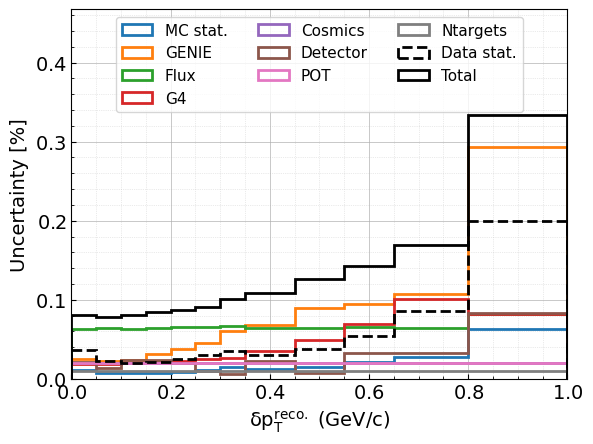

In [21]:
var_config = VariableConfig.tki_del_Tp()
syst_unc, syst_cov_matrix = get_syst_unc(var_config, plot=True, save_fig=False)

No intime cosmics provided


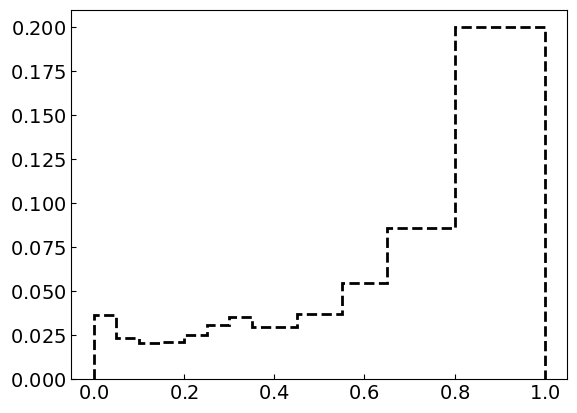

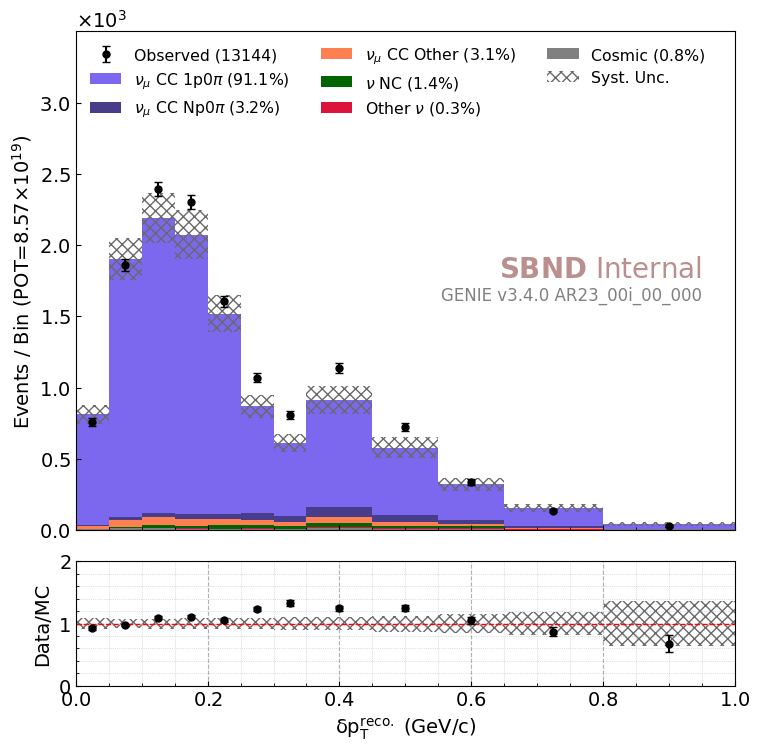

Diagonal ratio: 0.64
True ratio: [0.67265625 0.63963661 0.61597406 0.61100746 0.61398176 0.56468674
 0.534689   0.75506894 0.77307692 0.79512195 0.84210526 0.81132075]


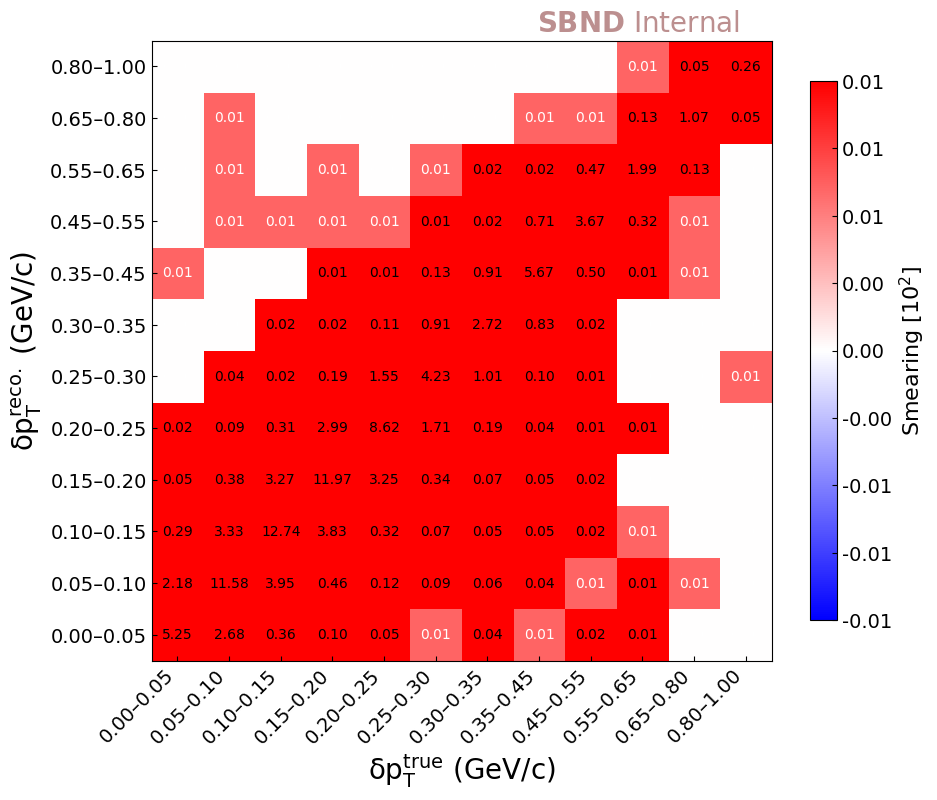

[0.18366811 0.18750772 0.18330455 0.18587274 0.18372577 0.17186813
 0.15450295 0.15321337 0.14816218 0.13637795 0.10829016 0.08507223]
Diagonal ratio: 0.67
True ratio: [0.6154396  0.62574062 0.61524875 0.61714824 0.61639058 0.59164535
 0.58815789 0.78104027 0.77109974 0.75288684 0.84210526 0.81132075]


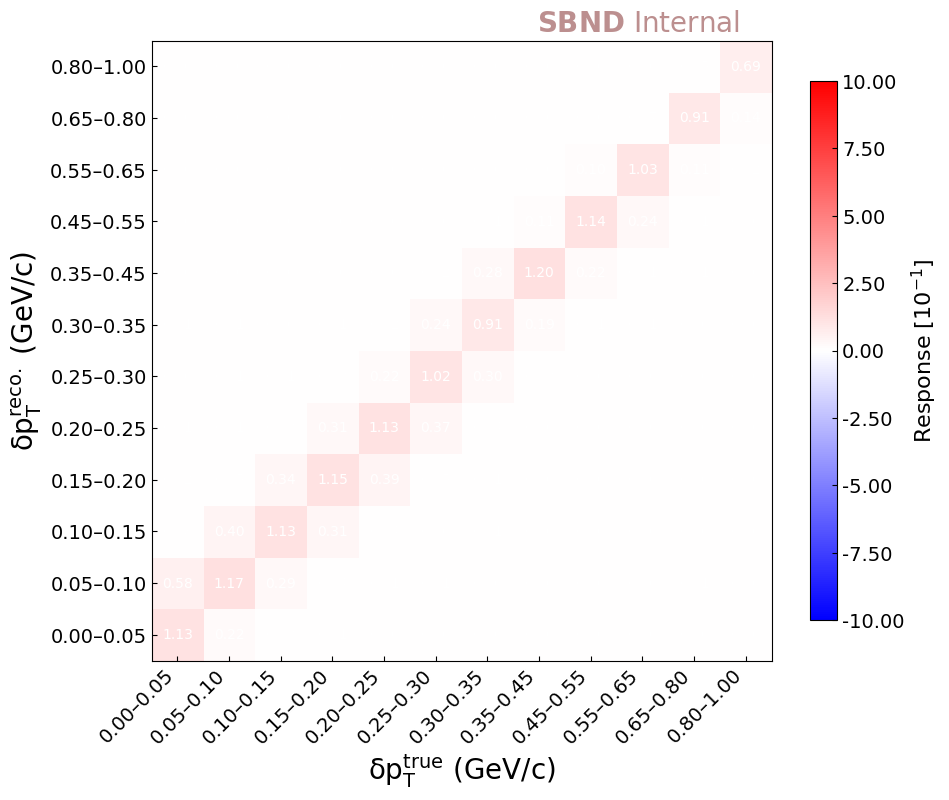

Unfolded perwidth:  [ 4.37021943e-37  9.16178861e-37  1.25323161e-36  1.16684803e-36
  7.85495430e-37  4.62277095e-37  4.16058260e-37  2.57831314e-37
  2.05222125e-37  9.73801248e-38  3.76092727e-38 -2.00148342e-39]
Model smeared perwidth:  [4.62520713e-37 9.26535161e-37 1.11413348e-36 9.83558034e-37
 7.24370926e-37 3.92107452e-37 2.81921247e-37 2.26944601e-37
 1.65288257e-37 9.28729357e-38 4.03443202e-38 7.92406173e-39]


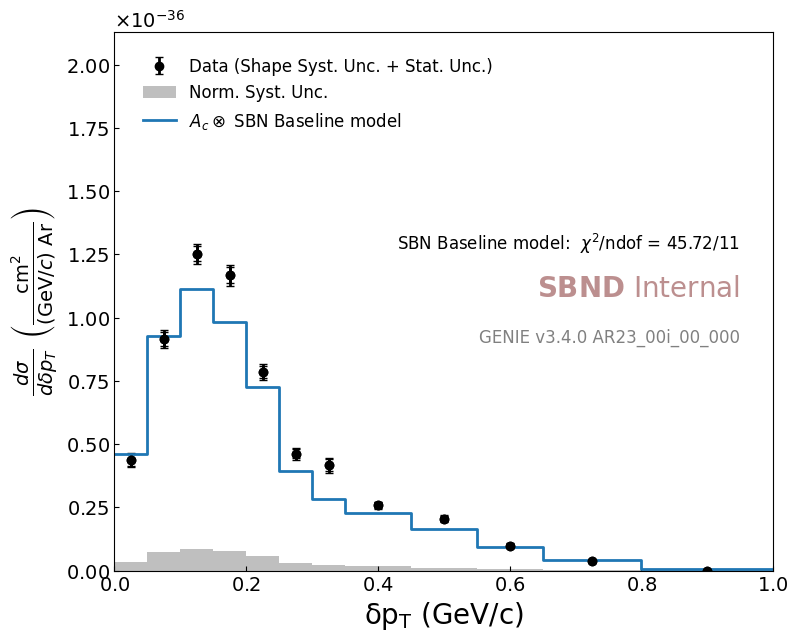

Diagonal ratio: 0.65
True ratio: [0.62084988 0.60565693 0.64312933 0.62419956 0.61972689 0.63716795
 0.50880081 0.73068403 0.77237424 0.70693132 0.84412333 0.89703786]


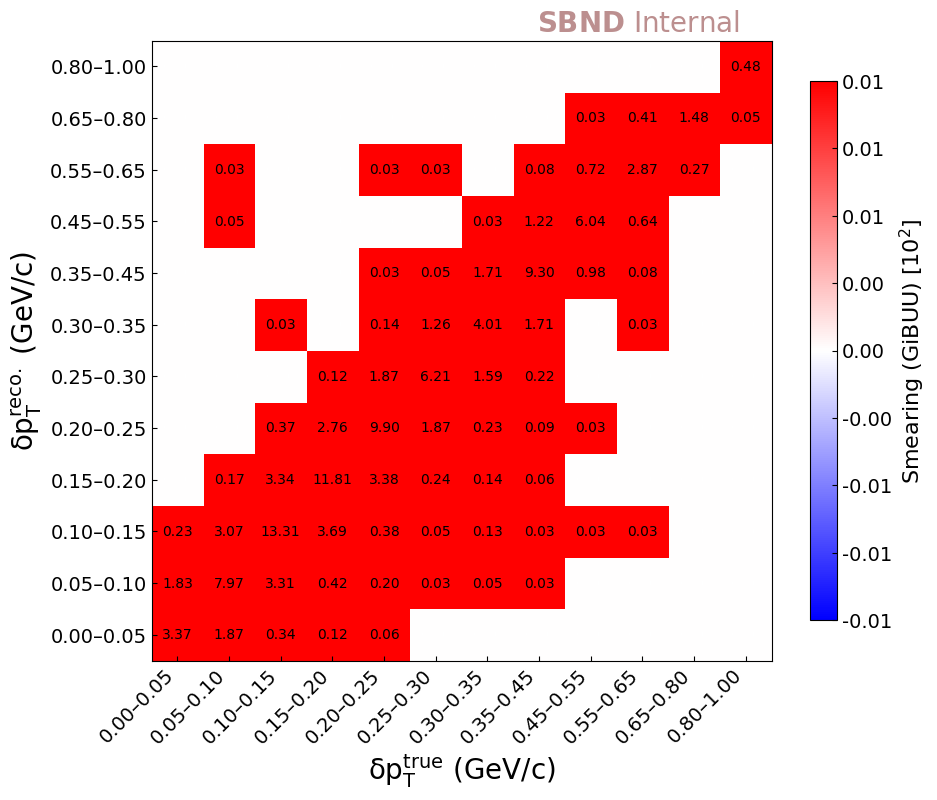

Diagonal ratio: 0.67
True ratio: [0.5846592  0.57596822 0.63575895 0.61690486 0.64963242 0.6208563
 0.56000904 0.76481646 0.75626421 0.71360995 0.7511257  1.        ]


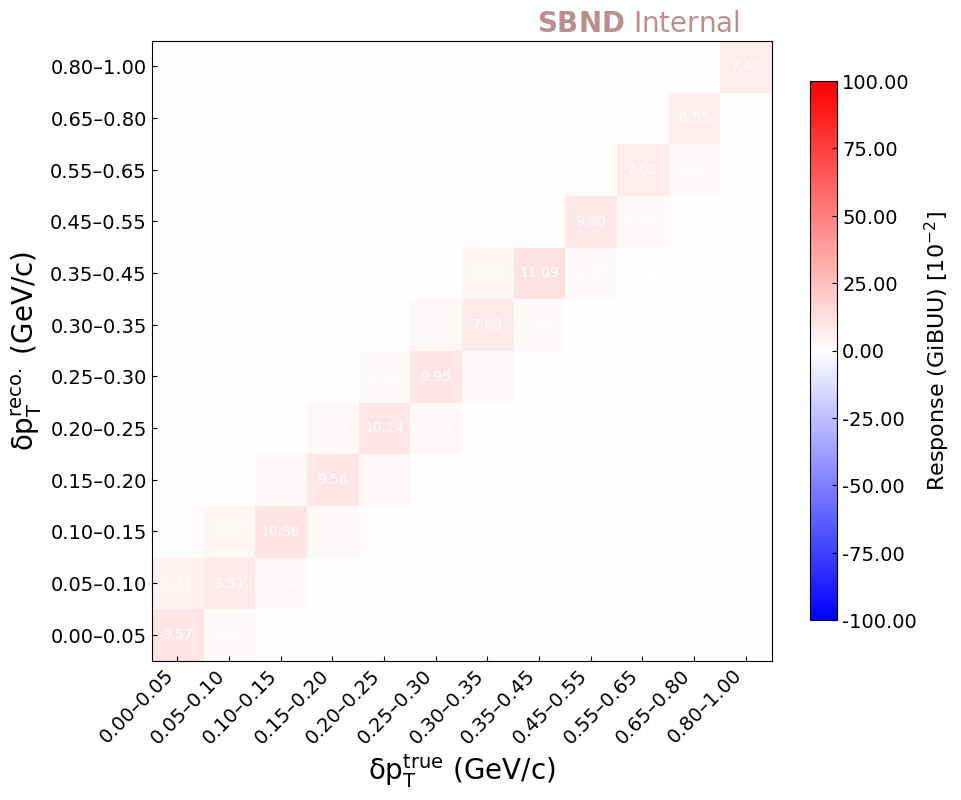

Unfolded perwidth:  [ 4.37021943e-37  9.16178861e-37  1.25323161e-36  1.16684803e-36
  7.85495430e-37  4.62277095e-37  4.16058260e-37  2.57831314e-37
  2.05222125e-37  9.73801248e-38  3.76092727e-38 -2.00148342e-39]
Model smeared perwidth:  [3.42504679e-37 8.67633947e-37 1.20856803e-36 1.16917018e-36
 9.15267381e-37 5.57566168e-37 5.34904987e-37 3.82850824e-37
 3.12348947e-37 1.86199099e-37 7.20674673e-38 1.42738229e-38]


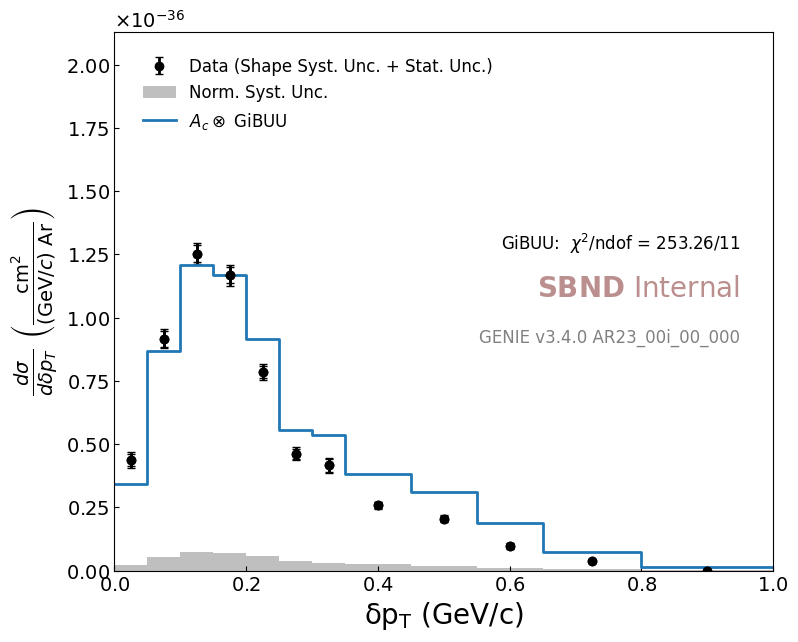

Unfolded perwidth:  [ 4.37021943e-37  9.16178861e-37  1.25323161e-36  1.16684803e-36
  7.85495430e-37  4.62277095e-37  4.16058260e-37  2.57831314e-37
  2.05222125e-37  9.73801248e-38  3.76092727e-38 -2.00148342e-39]
Model smeared perwidth:  [4.62520713e-37 9.26535161e-37 1.11413348e-36 9.83558034e-37
 7.24370926e-37 3.92107452e-37 2.81921247e-37 2.26944601e-37
 1.65288257e-37 9.28729357e-38 4.03443202e-38 7.92406173e-39]
Unfolded perwidth:  [ 4.37021943e-37  9.16178861e-37  1.25323161e-36  1.16684803e-36
  7.85495430e-37  4.62277095e-37  4.16058260e-37  2.57831314e-37
  2.05222125e-37  9.73801248e-38  3.76092727e-38 -2.00148342e-39]
Model smeared perwidth:  [3.42504679e-37 8.67633947e-37 1.20856803e-36 1.16917018e-36
 9.15267381e-37 5.57566168e-37 5.34904987e-37 3.82850824e-37
 3.12348947e-37 1.86199099e-37 7.20674673e-38 1.42738229e-38]


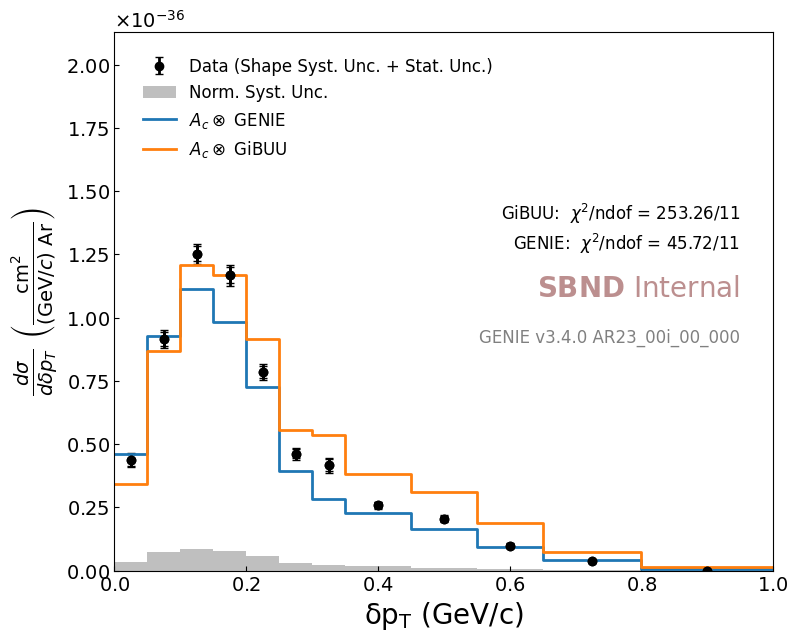

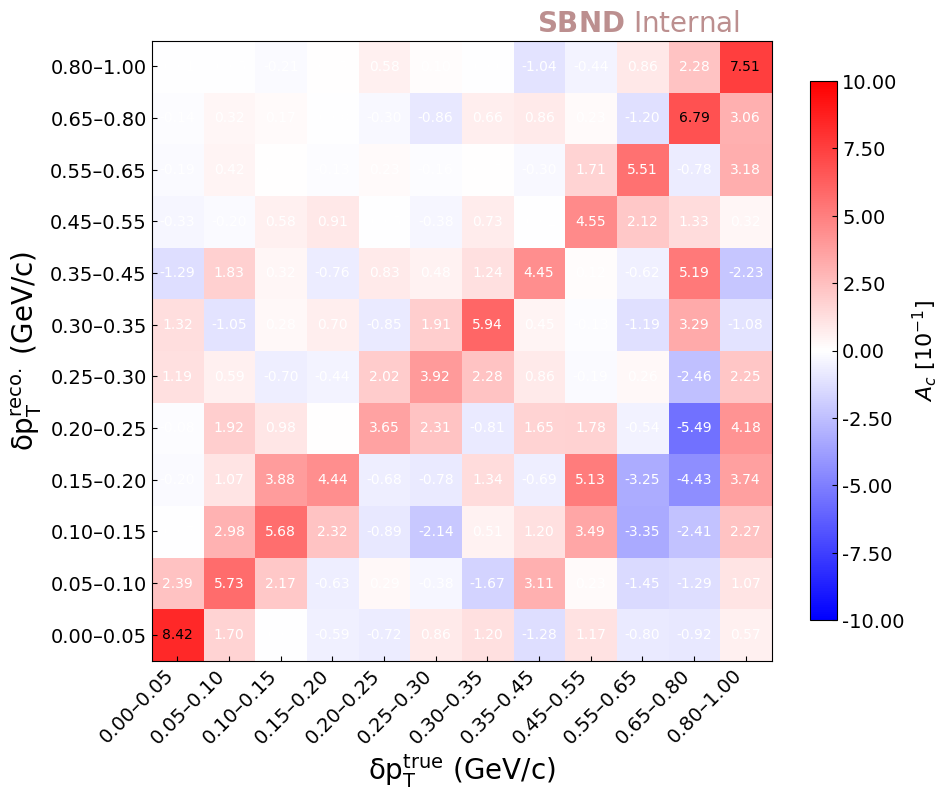

No intime cosmics provided


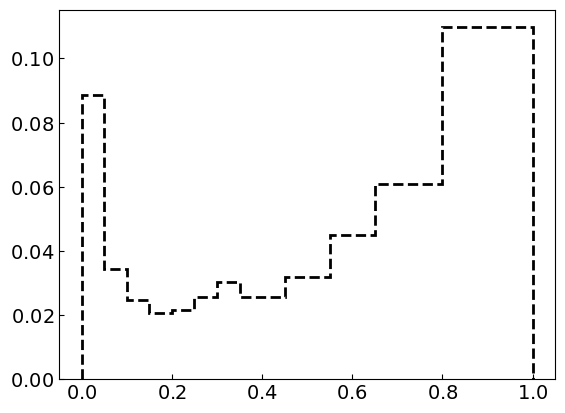

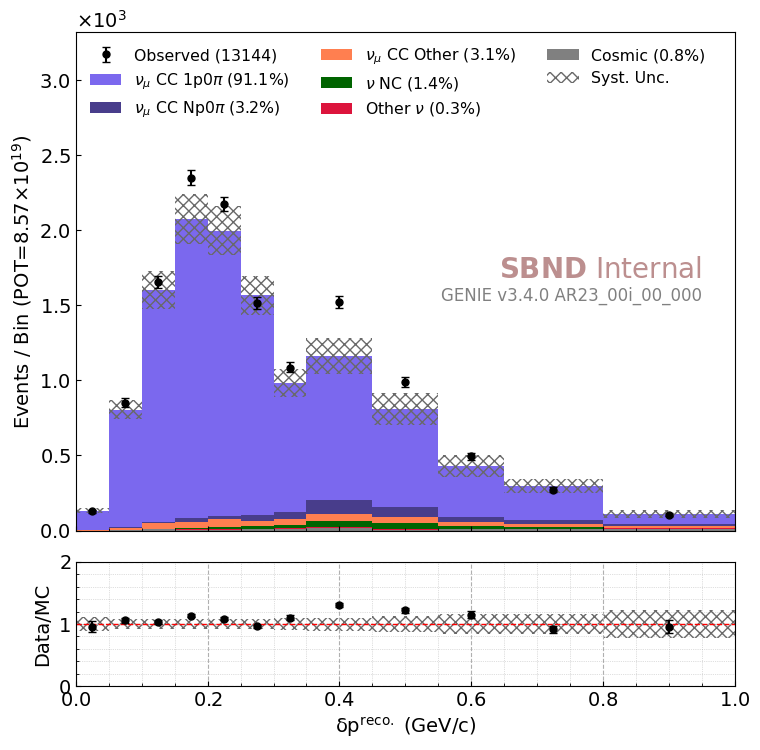

Diagonal ratio: 0.67
True ratio: [0.5258216  0.65264798 0.63981043 0.64549618 0.66345845 0.6605581
 0.63437058 0.76377454 0.76194939 0.7745975  0.80926431 0.77358491]


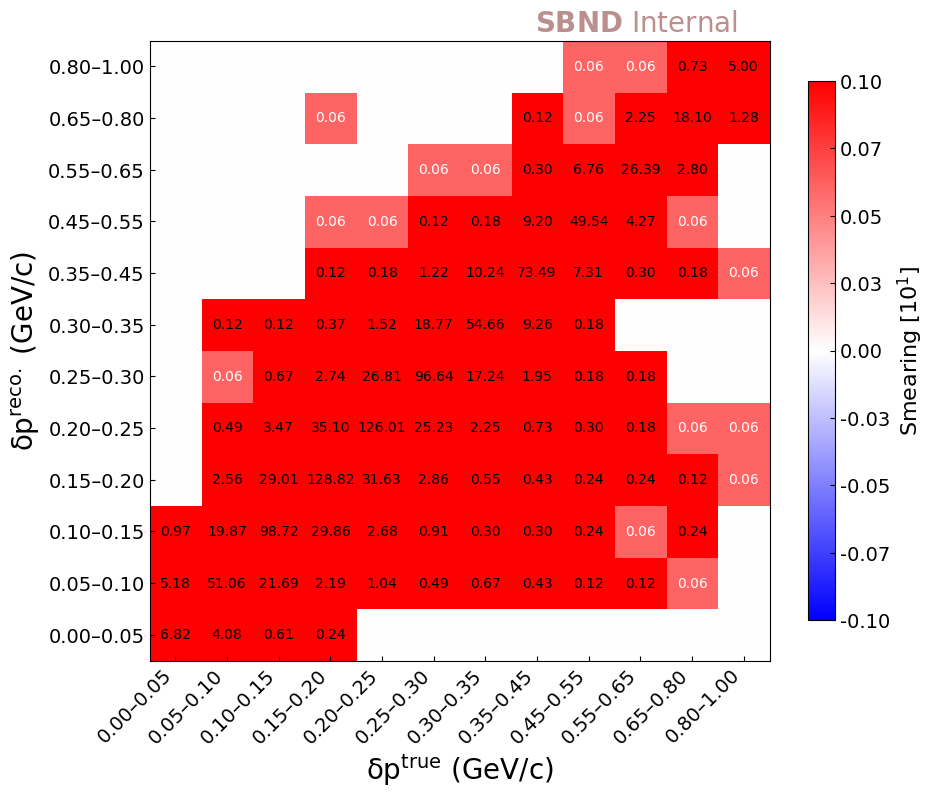

[0.19108911 0.1979091  0.19226385 0.19260631 0.19370548 0.18779783
 0.16732638 0.14747611 0.13604909 0.1259228  0.11307087 0.08026756]
Diagonal ratio: 0.68
True ratio: [0.58031088 0.61482025 0.64031621 0.65550388 0.64990572 0.65973378
 0.64301075 0.78926702 0.78023033 0.72529313 0.82729805 0.85416667]


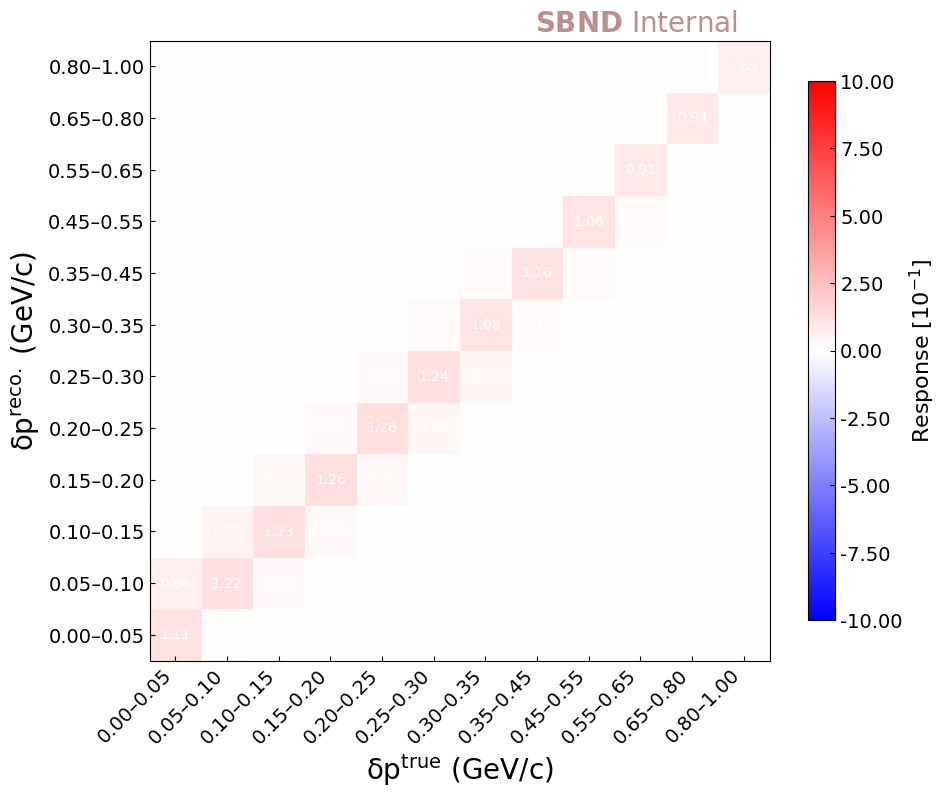

Unfolded perwidth:  [5.09269770e-38 4.13584305e-37 8.16908525e-37 1.14489678e-36
 1.11753092e-36 7.46768778e-37 5.78530626e-37 3.68642533e-37
 3.00137204e-37 1.91698237e-37 6.59186012e-38 1.48202464e-38]
Model smeared perwidth:  [5.70084043e-38 4.07273801e-37 7.86171826e-37 9.69200177e-37
 9.57646268e-37 7.41726153e-37 5.09182620e-37 2.80685127e-37
 2.27688868e-37 1.39802902e-37 5.78622873e-38 1.65188919e-38]


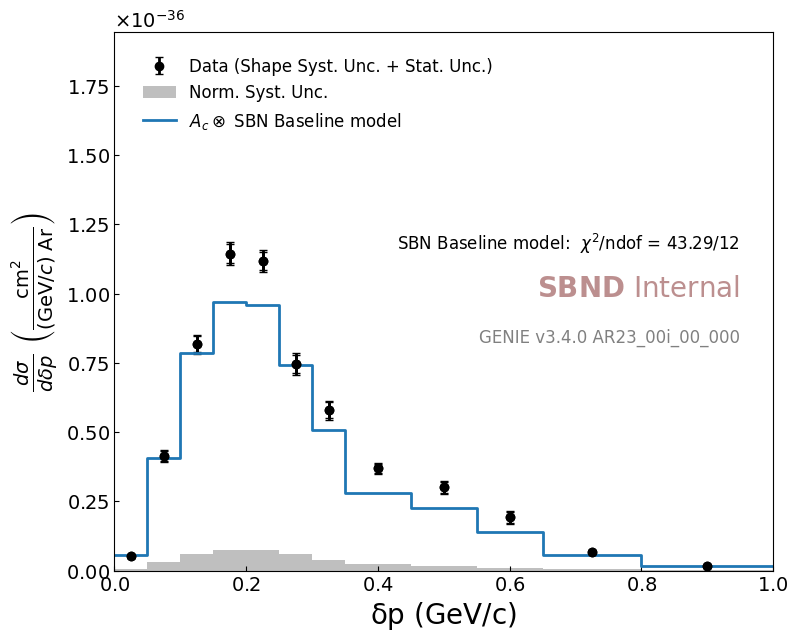

Diagonal ratio: 0.68
True ratio: [0.31016779 0.55853872 0.62497741 0.66097011 0.66381634 0.63800613
 0.61813132 0.7741061  0.78971032 0.76818314 0.784978   0.81579653]


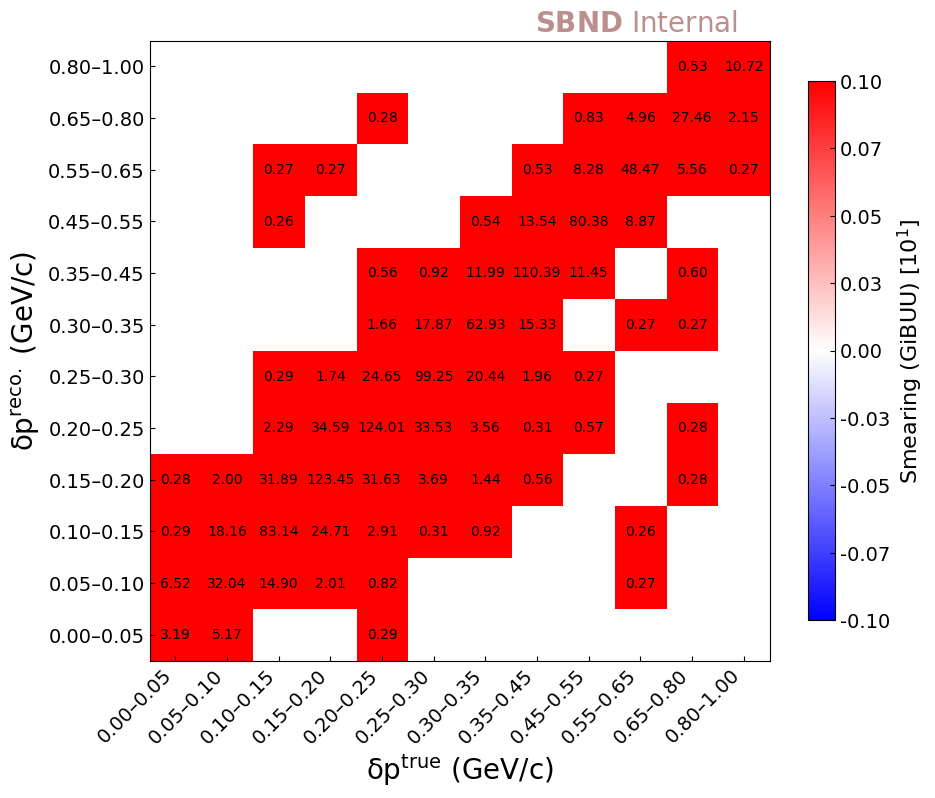

Diagonal ratio: 0.66
True ratio: [0.3686624  0.56641164 0.63617186 0.63242257 0.62273987 0.6679137
 0.64006437 0.81223457 0.77598198 0.76143718 0.76968487 0.95283852]


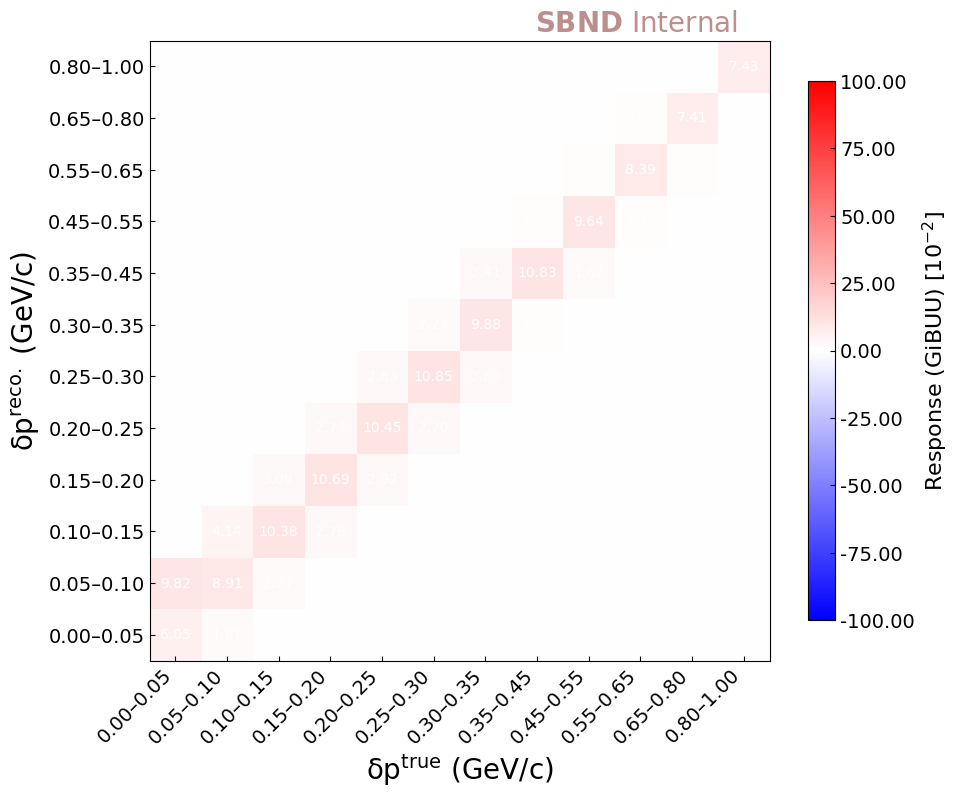

Unfolded perwidth:  [5.09269770e-38 4.13584305e-37 8.16908525e-37 1.14489678e-36
 1.11753092e-36 7.46768778e-37 5.78530626e-37 3.68642533e-37
 3.00137204e-37 1.91698237e-37 6.59186012e-38 1.48202464e-38]
Model smeared perwidth:  [5.43616669e-38 3.37567729e-37 7.82687100e-37 1.09331436e-36
 1.13942633e-36 8.65230164e-37 6.18854143e-37 4.47271145e-37
 3.97956411e-37 2.65996742e-37 1.02384553e-37 2.96833772e-38]


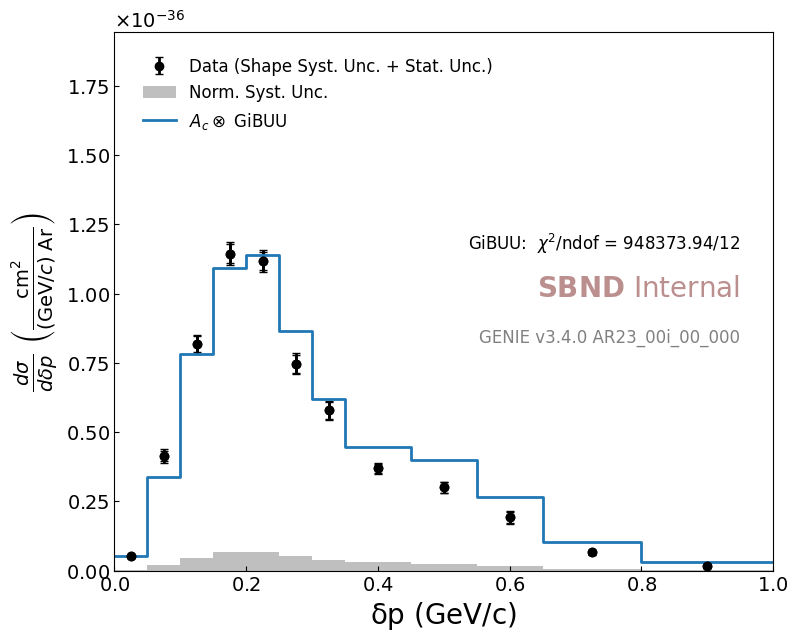

Unfolded perwidth:  [5.09269770e-38 4.13584305e-37 8.16908525e-37 1.14489678e-36
 1.11753092e-36 7.46768778e-37 5.78530626e-37 3.68642533e-37
 3.00137204e-37 1.91698237e-37 6.59186012e-38 1.48202464e-38]
Model smeared perwidth:  [5.70084043e-38 4.07273801e-37 7.86171826e-37 9.69200177e-37
 9.57646268e-37 7.41726153e-37 5.09182620e-37 2.80685127e-37
 2.27688868e-37 1.39802902e-37 5.78622873e-38 1.65188919e-38]
Unfolded perwidth:  [5.09269770e-38 4.13584305e-37 8.16908525e-37 1.14489678e-36
 1.11753092e-36 7.46768778e-37 5.78530626e-37 3.68642533e-37
 3.00137204e-37 1.91698237e-37 6.59186012e-38 1.48202464e-38]
Model smeared perwidth:  [5.43616669e-38 3.37567729e-37 7.82687100e-37 1.09331436e-36
 1.13942633e-36 8.65230164e-37 6.18854143e-37 4.47271145e-37
 3.97956411e-37 2.65996742e-37 1.02384553e-37 2.96833772e-38]


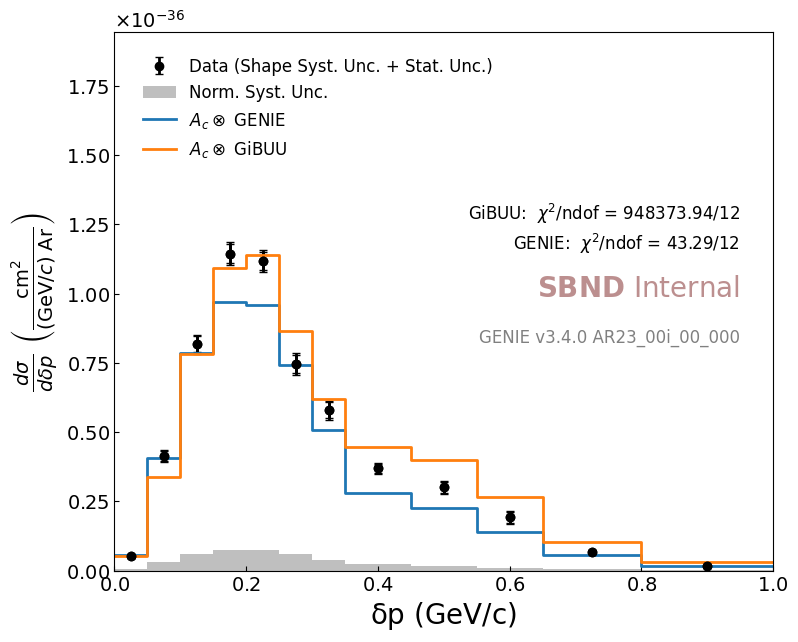

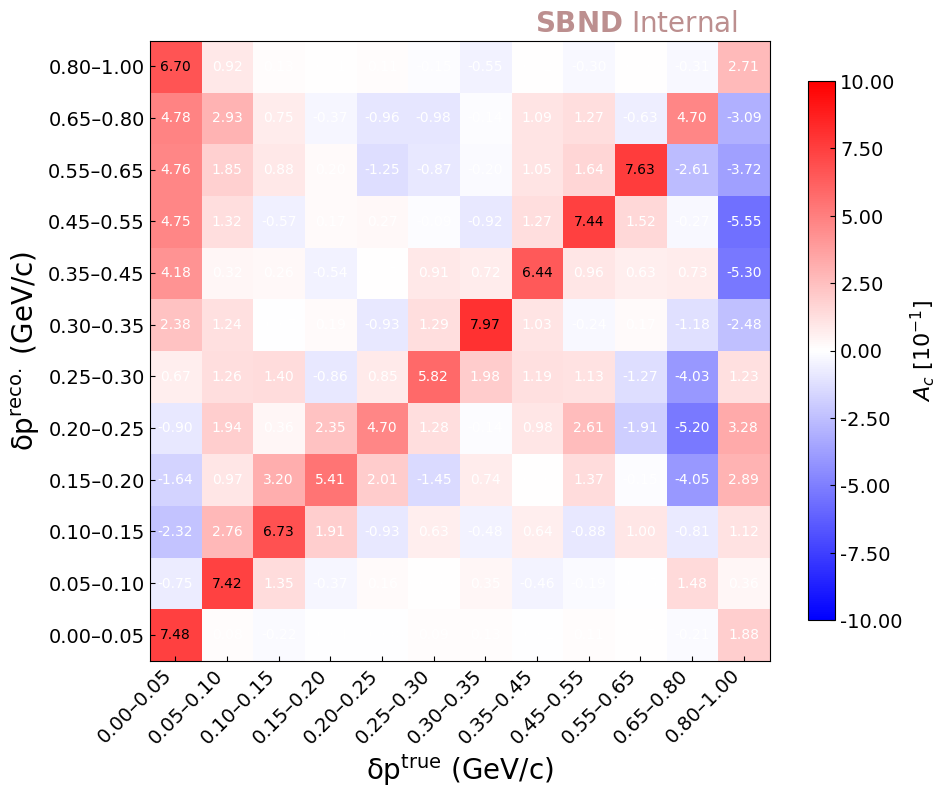

In [22]:
var_configs = [
    # VariableConfig.muon_momentum(),
    # VariableConfig.muon_direction(),
    # VariableConfig.proton_momentum(),
    # VariableConfig.proton_direction(),
    VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_p(),
    # VariableConfig.tki_del_alpha(),
    # VariableConfig.tki_del_phi(),
]

for var_config in var_configs:

    syst_unc, syst_cov_matrix = get_syst_unc(var_config, plot=False, save_fig=False)

    plot_labels_hist = [var_config.var_labels[1], pot_label, ""]
    ret = unfolding_plotter(var_config=var_config,
                            plot_labels=plot_labels_hist,
                            syst=syst_cov_matrix,
                            save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))
                            
    tot_frac_cov = syst_cov_matrix + np.diag(1/ret["total_data"])
    tot_cov = cov_from_fraccov(tot_frac_cov, ret["total_mc"])
    ret_chi2 = get_chi2(ret["total_data"], ret["total_mc"], tot_cov)

    evtdf_signal = mc_evt_df[mc_evt_df.topo_categ == 1]
    nudf_signal = mc_nu_df[mc_nu_df.topo_categ == 1]
    ret_signal_hists = signal_hists(mc_evt_df, mc_nu_df, var_config, mode="unfold", return_data=True, plot=False)

    save_fig_name = "{}/{}-reco_vs_true".format(save_fig_dir, var_config.var_save_name)
    if len(var_config.bins) == 2:
        reco_vs_true = np.array([[1.0]])
    else:
        reco_vs_true, _, _ = np.histogram2d(ret_signal_hists["var_sel_truth"], 
                                            ret_signal_hists["var_sel_reco"], 
                                            weights=ret_signal_hists["wgt_sel_truth"],
                                            bins=var_config.bins)

    plot_heatmap(reco_vs_true, 
                var_config.bins, 
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Smearing"],
                verbose=True,
                save_fig=save_fig, 
                save_name=save_fig_name)

    eff = ret_signal_hists["nevts_sel_truth"] / ret_signal_hists["nevts_allmc"]
    print(eff)

    save_fig_name = "{}/{}-response_matrix".format(save_fig_dir, var_config.var_save_name)
    response = get_response_matrix(reco_vs_true, eff)

    plot_heatmap(response, 
                var_config.bins, 
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
                save_fig=save_fig, 
                verbose=True,
                save_name=save_fig_name)


    nevts_sel_data = ret["total_data"] - ret["total_mc_bkgd"] 
    measured = nevts_sel_data * xsec_unit  # bkgd-subtracted data
    model    = ret_signal_hists["nevts_allmc"] * xsec_unit
    Covariance = cov_from_fraccov(syst_cov_matrix, ret_signal_hists["nevts_sel_reco"]) * xsec_unit**2 
    unfold = WienerSVD(response, model, measured, Covariance*1.1, C_type, Norm_type, stat_scaling=xsec_unit)
    # print(unfold.keys())
    # decomp_cov = Matrix_Decomp(model, unfold['SystUnfoldCov'])

    models = {"SBN Baseline model": model} #,  "AR23": nevts_dict["GENIE AR23"]}
    save_name = f"{save_fig_dir}/{var_config.var_save_name}-unfolded_event_rates-DATA"

    # if measured: do not overwrite zeros with O(1) in xsec units — that destroys Poisson stats

    plot_unfolded_result(unfold, 
                        measured, 
                        models, 
                        var_config,
                        # chi2_list = [float(ret_chi2[0])],
                        xsec_unit=xsec_unit,
                        save_fig=save_fig, 
                        save_name=save_name,
                        data=True,
                        closure_test=False)

    # GiBUU: same nevts_allmc axis; folded GiBUU curve uses Wiener AddSmear from GiBUU response (data unfold still GENIE).
    if gibuu_evt_df is not None and gibuu_mcnu_df is not None:
        ret_gibuu = signal_hists(
            gibuu_evt_df, gibuu_mcnu_df, var_config, mode="unfold", return_data=True, plot=False
        )
        model_gibuu = ret_gibuu["nevts_allmc"] * xsec_unit
        if len(var_config.bins) == 2:
            reco_vs_true_gibuu = np.array([[1.0]])
        else:
            reco_vs_true_gibuu, _, _ = np.histogram2d(
                ret_gibuu["var_sel_truth"],
                ret_gibuu["var_sel_reco"],
                weights=ret_gibuu["wgt_sel_truth"],
                bins=var_config.bins,
            )
        save_fig_name_gibuu_smear = "{}/{}-reco_vs_true-GiBUU".format(save_fig_dir, var_config.var_save_name)
        plot_heatmap(
            reco_vs_true_gibuu,
            var_config.bins,
            plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Smearing (GiBUU)"],
            verbose=True,
            save_fig=save_fig,
            save_name=save_fig_name_gibuu_smear,
        )
        eff_gibuu = ret_gibuu["nevts_sel_truth"] / ret_gibuu["nevts_allmc"]
        response_gibuu = get_response_matrix(reco_vs_true_gibuu, eff_gibuu)
        save_fig_name_gibuu_resp = "{}/{}-response_matrix-GiBUU".format(save_fig_dir, var_config.var_save_name)
        plot_heatmap(
            response_gibuu,
            var_config.bins,
            plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response (GiBUU)"],
            save_fig=save_fig,
            verbose=True,
            save_name=save_fig_name_gibuu_resp,
        )
        Covariance_gibuu = cov_from_fraccov(syst_cov_matrix, ret_gibuu["nevts_sel_reco"]) * xsec_unit**2
        unfold_gibuu = WienerSVD(
            response_gibuu,
            model_gibuu,
            measured,
            Covariance_gibuu * 1.1,
            C_type,
            Norm_type,
            stat_scaling=xsec_unit,
        )
        smear_gibuu = unfold_gibuu["AddSmear"]
        save_name_gibuu = f"{save_fig_dir}/{var_config.var_save_name}-unfolded_event_rates-DATA-GiBUU"
        plot_unfolded_result(
            unfold,
            measured,
            {"GiBUU": model_gibuu},
            var_config,
            xsec_unit=xsec_unit,
            save_fig=save_fig,
            save_name=save_name_gibuu,
            data=True,
            closure_test=False,
            model_add_smear={"GiBUU": smear_gibuu},
        )
        save_name_both = f"{save_fig_dir}/{var_config.var_save_name}-unfolded_event_rates-DATA-GENIE-GiBUU"
        plot_unfolded_result(
            unfold,
            measured,
            {"GENIE": model, "GiBUU": model_gibuu},
            var_config,
            xsec_unit=xsec_unit,
            save_fig=save_fig,
            save_name=save_name_both,
            data=True,
            closure_test=False,
            model_add_smear={"GiBUU": smear_gibuu},
        )

    save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "data")
    plot_heatmap(unfold["AddSmear"], 
                var_config.bins, 
                plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
                save_fig=save_fig, 
                save_name=save_fig_name)

In [23]:
save_fig_dir

'/exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding-data-20260513'